<a href="https://www.kaggle.com/code/kelvinswai/ai-impact-in-health-prediction-and-eda?scriptVersionId=332052748" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Healthcare AI Impact & Patient Wellness Dataset

## 📌 Context
This dataset captures an empirical study conducted within a healthcare facility to evaluate the clinical and operational impact of integrating various Artificial Intelligence (AI) digital health tools. It tracks patient demographics, physical health habits, chronic conditions, and digital engagement metrics over a specific observation period to measure overall healthcare outcomes and patient satisfaction.

## 📊 Content & Feature Definitions
The dataset contains several features monitoring patient attributes, app usage, and clinical metrics:

*   **Participant_ID**: Unique identifier for each patient.
*   **Age & Age_Group**: The patient's chronological age and demographic bucket.
*   **Gender**: Demographic gender of the participant.
*   **Chronic_Condition**: Binary indicator of whether the patient has a long-term illness.
*   **BMI & BMI_Category**: Body Mass Index continuous score and its clinical classification (Underweight, Normal, Overweight, Obese).
*   **AI_Tool_Type**: The specific digital AI architecture deployed (e.g., Symptom Checkers, Diet Trackers).
*   **AI_Health_App_Usage_Hours_Per_Week**: Weekly time investment on the AI platform.
*   **AI_Usage_Level**: Categorized frequency of application use (Low, Medium, High).
*   **Exercise_Hours_Per_Week & Exercise_Level**: Physical activity tracking metrics.
*   **Total_Engagement_Hours_Per_Week**: Combined digital and physical health tracking hours.
*   **Health_Score_Before_AI & Health_Score_After_AI**: Baseline and post-intervention health indices.
*   **Improvement**: The net change in health score ($\text{After} - \text{Before}$).
*   **Satisfaction_Score & Satisfaction_Level**: Patient-reported qualitative feedback regarding the AI platform.
*   **Risk_Category**: Clinical risk stratification of the patient.

## 🎯 Primary Analytical Goals (EDA Inquiries)
1. Evaluate which **AI Tool Type** yields the highest therapeutic return (`Improvement`).
2. Identify correlations between digital engagement levels (`AI_Usage_Level`) and user experience metrics (`Satisfaction_Score`).
3. Screen out mathematical artifacts and engineered feature noise (e.g., `Improvement_Per_AI_Hour`) to prepare the data architecture for robust Machine Learning modeling.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Load Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/gauravjhaeigenvector/ai-impact-on-health/AI_Impact_on_Health_Dataset_5000_Enhanced.csv')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
df.head()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,Exercise_Hours_Per_Week,Exercise_Level,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,9,Active,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,11,Active,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,4,Moderate,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,1,Sedentary,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,1,Sedentary,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium


#### Show five last rows

In [3]:
df.tail()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,Exercise_Hours_Per_Week,Exercise_Level,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
4995,4996,42,36-45,Female,Yes,20.0,Normal,Fitness Tracker,19,High,0,Sedentary,19,57,58,1,1.75,Improved,0.05,10,High,Medium
4996,4997,39,36-45,Female,Yes,22.7,Normal,Diagnostic Assistant,16,High,4,Moderate,20,52,57,5,9.62,Improved,0.29,5,Medium,Medium
4997,4998,48,46-55,Female,No,26.8,Overweight,Mental Health App,13,Medium,12,Active,25,61,71,10,16.39,Improved,0.71,3,Low,Low
4998,4999,34,26-35,Female,Yes,27.9,Overweight,Telemedicine,13,Medium,2,Sedentary,15,53,72,19,35.85,Highly Improved,1.36,2,Low,Medium
4999,5000,72,66-79,Male,No,22.0,Normal,Diagnostic Assistant,2,Low,4,Moderate,6,50,56,6,12.00,Improved,2.00,6,Medium,Low


#### shape of dataset

In [4]:
df.shape

(5000, 22)

#### Check if there is duplicates/repeating rows in dataset

In [5]:
df.duplicated().sum()

np.int64(0)

###### int64(0) means that there is 0 duplicates hence there is no duplicated rows in our dataset

#### Check if there is null/Not Available Value in dataset

In [6]:
df.isnull().sum().to_frame(name='Null Count')

,Null Count
Participant_ID,0
Age,0
Age_Group,0
Gender,0
Chronic_Condition,0
BMI,0
BMI_Category,0
AI_Tool_Type,0
AI_Health_App_Usage_Hours_Per_Week,0
AI_Usage_Level,0


#### Show information of dataset for Numeric and categorical columns

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Participant_ID                      5000 non-null   int64  
 1   Age                                 5000 non-null   int64  
 2   Age_Group                           5000 non-null   object 
 3   Gender                              5000 non-null   object 
 4   Chronic_Condition                   5000 non-null   object 
 5   BMI                                 5000 non-null   float64
 6   BMI_Category                        5000 non-null   object 
 7   AI_Tool_Type                        5000 non-null   object 
 8   AI_Health_App_Usage_Hours_Per_Week  5000 non-null   int64  
 9   AI_Usage_Level                      5000 non-null   object 
 10  Exercise_Hours_Per_Week             5000 non-null   int64  
 11  Exercise_Level                      5000 no

#### To show unique counts of items in each columns

In [8]:
df.nunique().to_frame(name='unique counts')

,unique counts
Participant_ID,5000
Age,62
Age_Group,6
Gender,3
Chronic_Condition,2
BMI,238
BMI_Category,4
AI_Tool_Type,4
AI_Health_App_Usage_Hours_Per_Week,21
AI_Usage_Level,3


#### Show Numeric Stastics of Dataset

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Participant_ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.50,3750.25,5000.0
Age,5000.0,48.805600,17.906991,18.0,34.00,49.00,64.00,79.0
BMI,5000.0,25.017560,3.980900,10.6,22.40,25.05,27.70,38.6
AI_Health_App_Usage_Hours_Per_Week,5000.0,10.235600,6.016389,0.0,5.00,10.50,15.00,20.0
Exercise_Hours_Per_Week,5000.0,7.047000,4.299033,0.0,3.00,7.00,11.00,14.0
Total_Engagement_Hours_Per_Week,5000.0,17.282600,7.424673,0.0,12.00,17.00,23.00,34.0
Health_Score_Before_AI,5000.0,64.432200,14.563015,40.0,52.00,64.00,77.00,89.0
Health_Score_After_AI,5000.0,71.734000,16.016446,35.0,59.00,72.00,84.00,100.0
Improvement,5000.0,7.301800,7.358230,-5.0,1.00,7.00,13.00,20.0
Improvement_Percentage,5000.0,12.097002,13.010823,-12.5,1.45,11.41,21.28,50.0


#### Create variable for numerical and categorical columns

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

#### To check outliers in dataset(By Using IQR)

In [11]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR =  Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum().to_frame(name='outliers')

,outliers
Participant_ID,0
Age,0
BMI,43
AI_Health_App_Usage_Hours_Per_Week,0
Exercise_Hours_Per_Week,0
Total_Engagement_Hours_Per_Week,0
Health_Score_Before_AI,0
Health_Score_After_AI,0
Improvement,0
Improvement_Percentage,0


#### This boxplot show outliers 

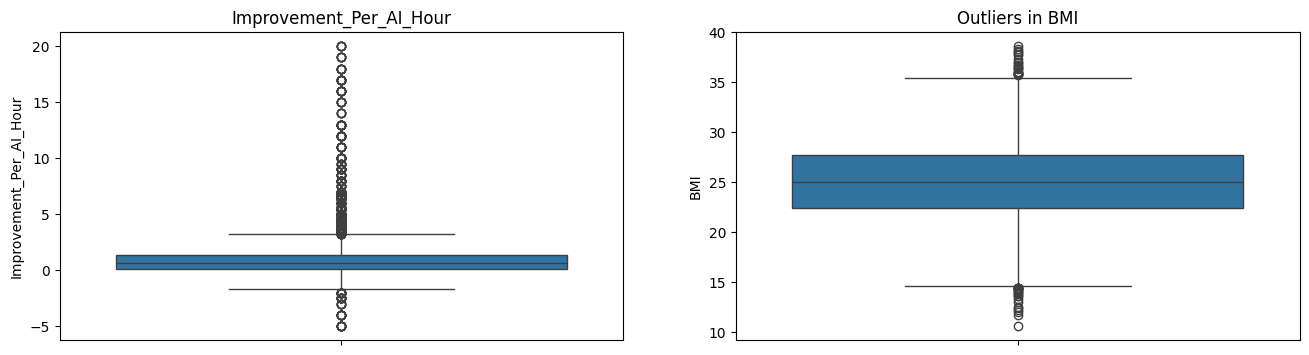

In [12]:
fig, ax =plt.subplots(1,2, figsize=(16,4))

sns.boxplot(df['Improvement_Per_AI_Hour'], ax=ax[0])
ax[0].set_title('Improvement_Per_AI_Hour')

sns.boxplot(df['BMI'], ax=ax[1])
ax[1].set_title('Outliers in BMI')

plt.show()

#### To show correlation_matrix between pair of features

In [13]:
from IPython.display import display

corr = df[num_cols].corr().round(2)

display(corr)

,Participant_ID,Age,BMI,AI_Health_App_Usage_Hours_Per_Week,Exercise_Hours_Per_Week,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Per_AI_Hour,Satisfaction_Score
Participant_ID,1.00,-0.01,-0.01,0.03,-0.01,0.01,0.02,0.02,0.00,-0.01,-0.01,-0.02
Age,-0.01,1.00,0.03,0.02,0.03,0.03,0.03,0.02,-0.00,-0.01,0.00,-0.02
BMI,-0.01,0.03,1.00,0.03,-0.00,0.02,0.00,0.00,0.01,0.01,-0.03,-0.01
AI_Health_App_Usage_Hours_Per_Week,0.03,0.02,0.03,1.00,0.01,0.82,-0.01,-0.01,0.01,0.01,-0.42,-0.01
Exercise_Hours_Per_Week,-0.01,0.03,-0.00,0.01,1.00,0.59,0.01,0.01,-0.00,-0.01,0.00,-0.00
Total_Engagement_Hours_Per_Week,0.01,0.03,0.02,0.82,0.59,1.00,-0.00,-0.00,0.00,0.00,-0.34,-0.01
Health_Score_Before_AI,0.02,0.03,0.00,-0.01,0.01,-0.00,1.00,0.89,-0.05,-0.26,-0.02,-0.00
Health_Score_After_AI,0.02,0.02,0.00,-0.01,0.01,-0.00,0.89,1.00,0.42,0.20,0.20,-0.01
Improvement,0.00,-0.00,0.01,0.01,-0.00,0.00,-0.05,0.42,1.00,0.95,0.49,-0.03
Improvement_Percentage,-0.01,-0.01,0.01,0.01,-0.01,0.00,-0.26,0.20,0.95,1.00,0.47,-0.02


### EXPLORATORY DATA ANALYSIS(EDA)

#### 1.Age Distribution

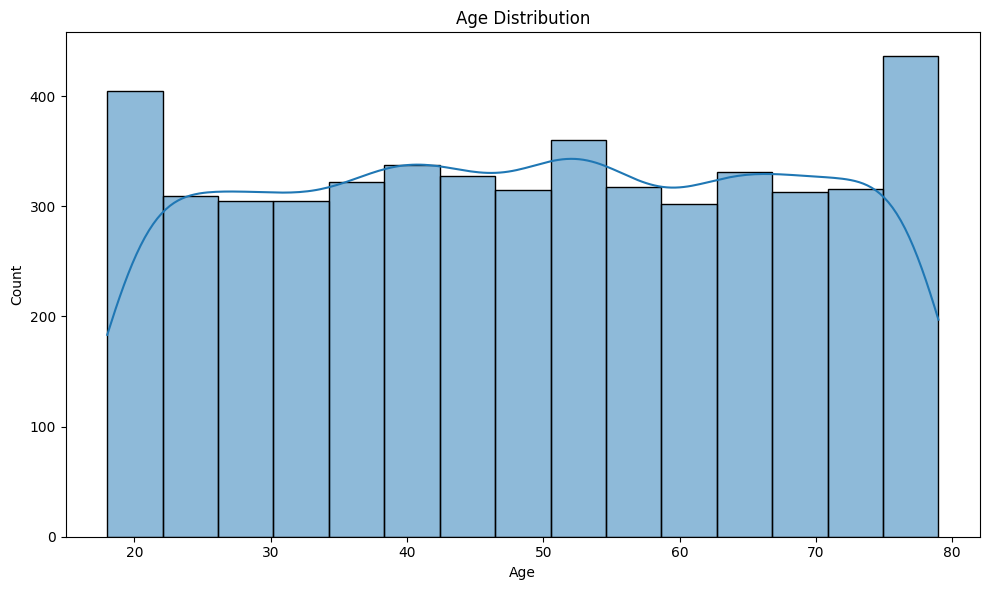

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x = 'Age', bins=15, binrange=(18,79), kde=True, edgecolor='black')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

***insight**.
The histogram shows the distribution of participants' Ages, while the KDE curve provides a smoothed estimate of the distribution.The ages are spread across a wide range with no dominant age group, suggesting relatively balanced sample

#### 2.Gender counts

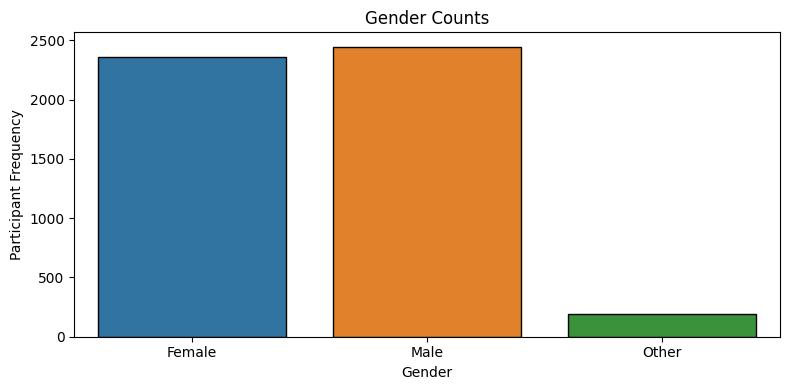

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Gender', edgecolor='black', palette='tab10')
plt.title('Gender Counts')
plt.ylabel('Participant Frequency')
plt.tight_layout()
plt.show()

#### 3.Chronic_Condition Distribution

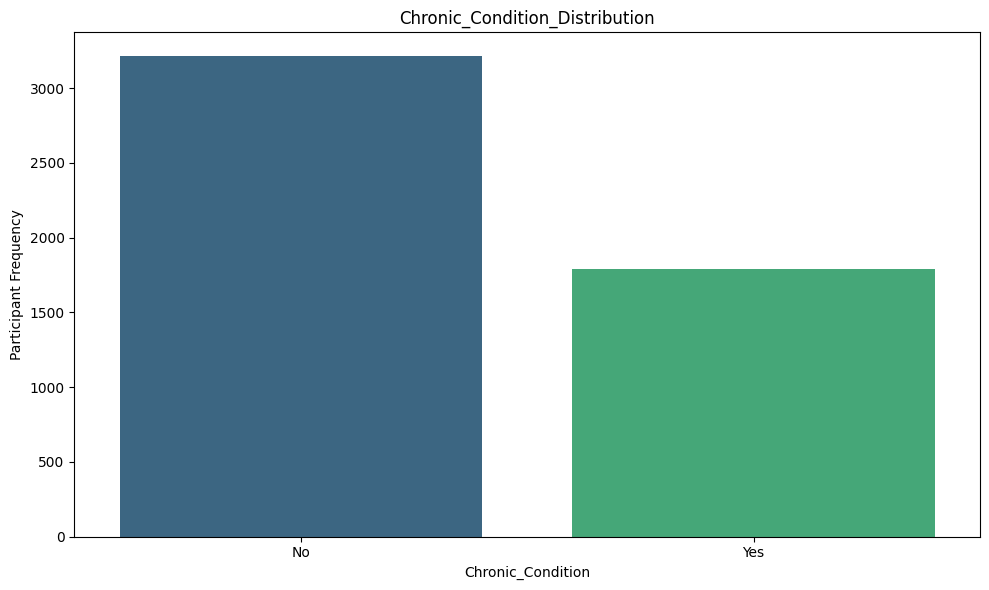

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Chronic_Condition', palette='viridis')
plt.title('Chronic_Condition_Distribution')
plt.ylabel('Participant Frequency')
plt.tight_layout()
plt.show()


The countplot show that individuals without chronic diseases are more than those with chronic diseases.Specifically, there are over 3000 individuals without chronic condition, While approximately 1800 indivduals are affected.this indicate dataset is imbalanced...

#### 4.BMI vs BMI_Category

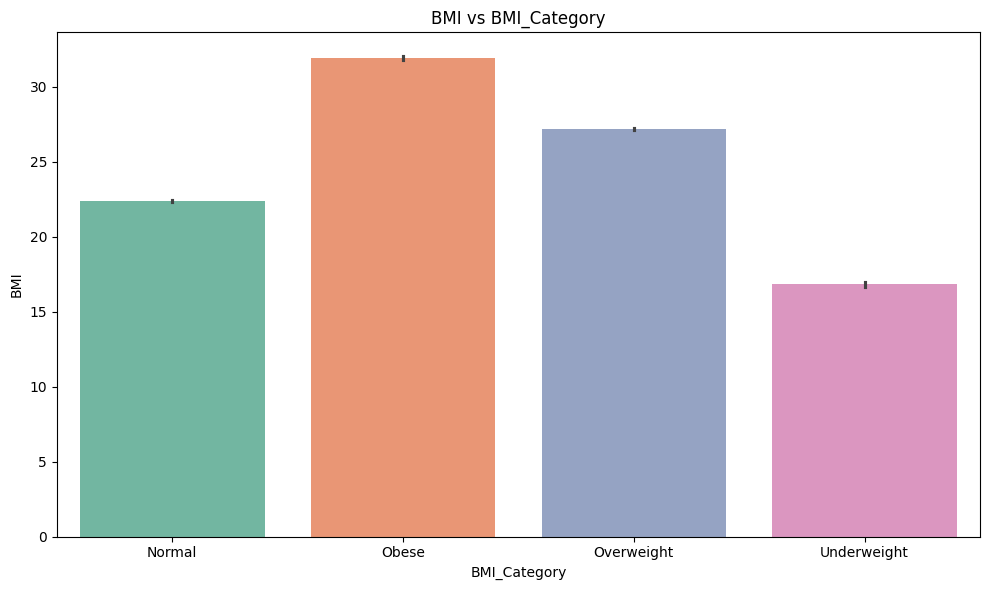

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='BMI_Category', y='BMI', palette='Set2')
plt.title('BMI vs BMI_Category')
plt.tight_layout()
plt.show()

#### 5. Participant_Count by Age_Group

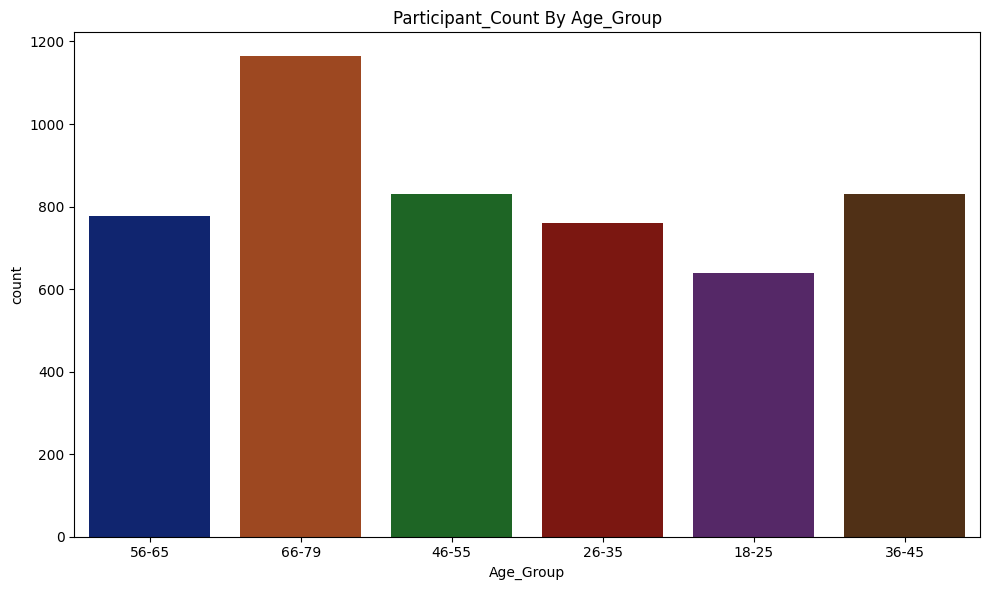

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Age_Group', palette='dark')
plt.title('Participant_Count By Age_Group')
plt.tight_layout()
plt.show()

##### 6. AI_app_usage vs Exercise(Hours)

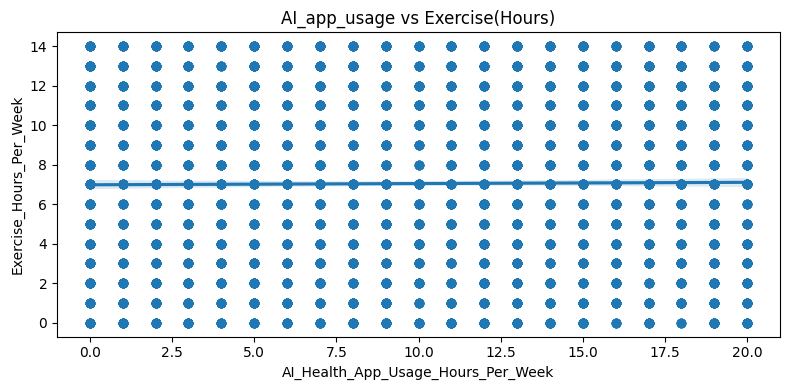

In [19]:
plt.figure(figsize=(8,4))
sns.regplot(x='AI_Health_App_Usage_Hours_Per_Week', y='Exercise_Hours_Per_Week' ,data=df)
plt.title('AI_app_usage vs Exercise(Hours)')
plt.tight_layout()
plt.show()

To identify which specif AI tool type is utilized for the highest number of hours per week by patients

#### 7. AI_app_Usage vs AI_tool

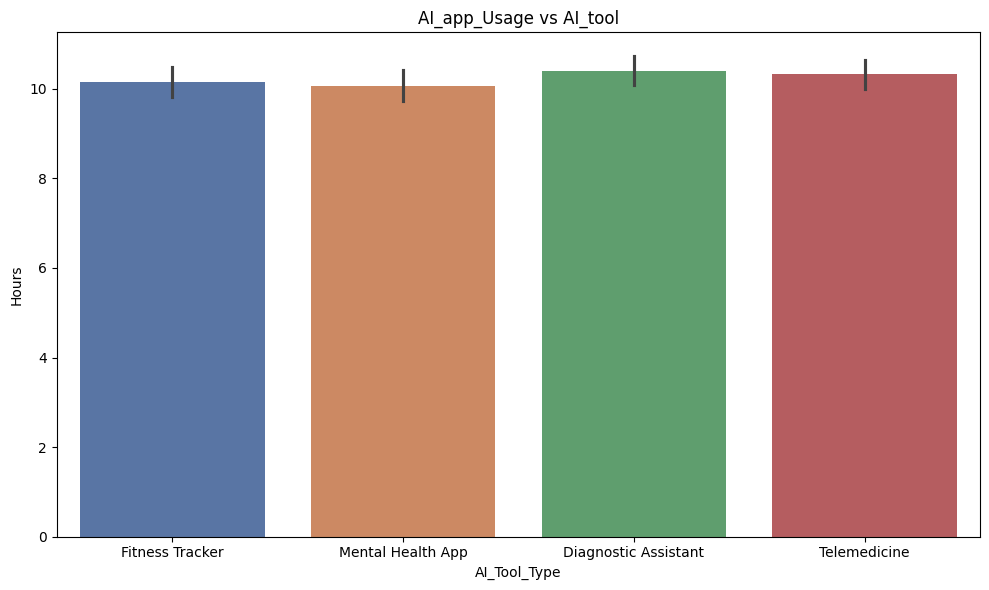

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(df, y=df['AI_Health_App_Usage_Hours_Per_Week'], x=df['AI_Tool_Type'], palette='deep')
plt.title('AI_app_Usage vs AI_tool')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()

#### 8. Exercise_per_week vs Chronic_Condition
Do patients with chronic condition engage in fewer hours of exercise per week compared to those without??

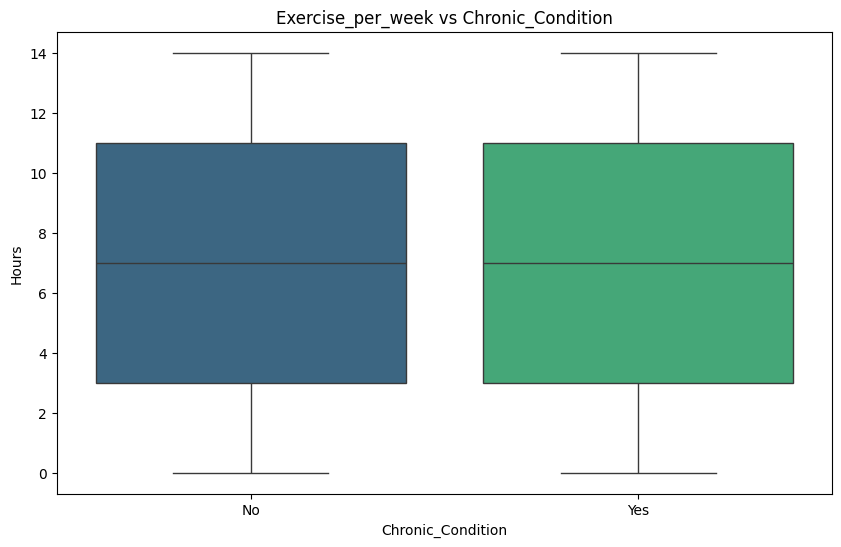

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(df, x=df['Chronic_Condition'], y=df['Exercise_Hours_Per_Week'], palette='viridis')
plt.title('Exercise_per_week vs Chronic_Condition')
plt.ylabel('Hours')
plt.show()

The boxplot visualize that patients with long term illiness can perform their body exercise(in Hours) as to those without chronic diseases.It means that chronic condition is not a reason for patients to unable perform their exercise

#### 9. Age vs Total_Engagement by Gender


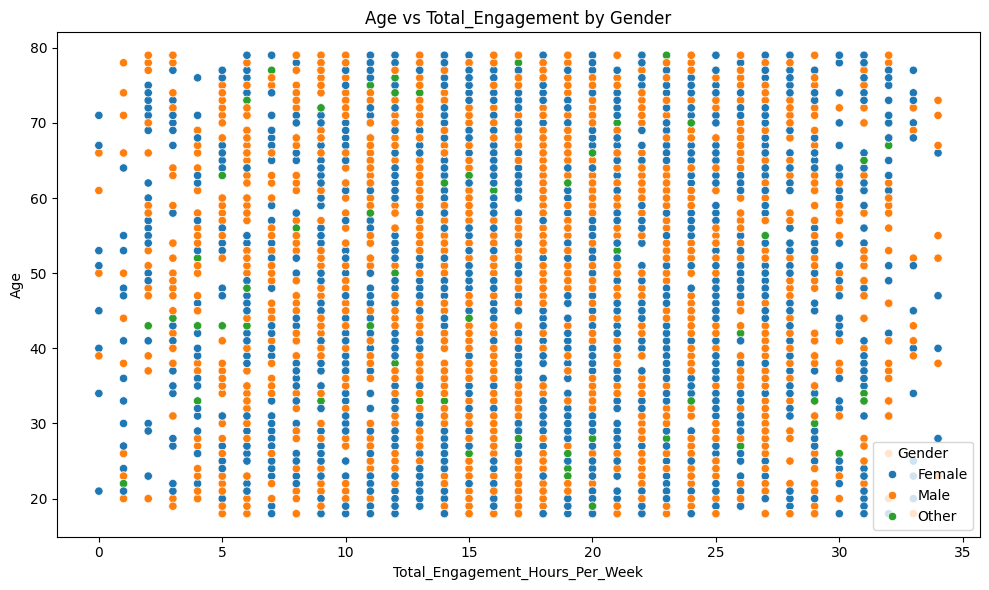

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(df, y=df['Age'], x=df['Total_Engagement_Hours_Per_Week'], hue=df['Gender'])
plt.title('Age vs Total_Engagement by Gender')
plt.tight_layout()
plt.show()

#### 10. Health_Before_AI vs Health_After_AI

to show how health condition are related to AI in our dataset

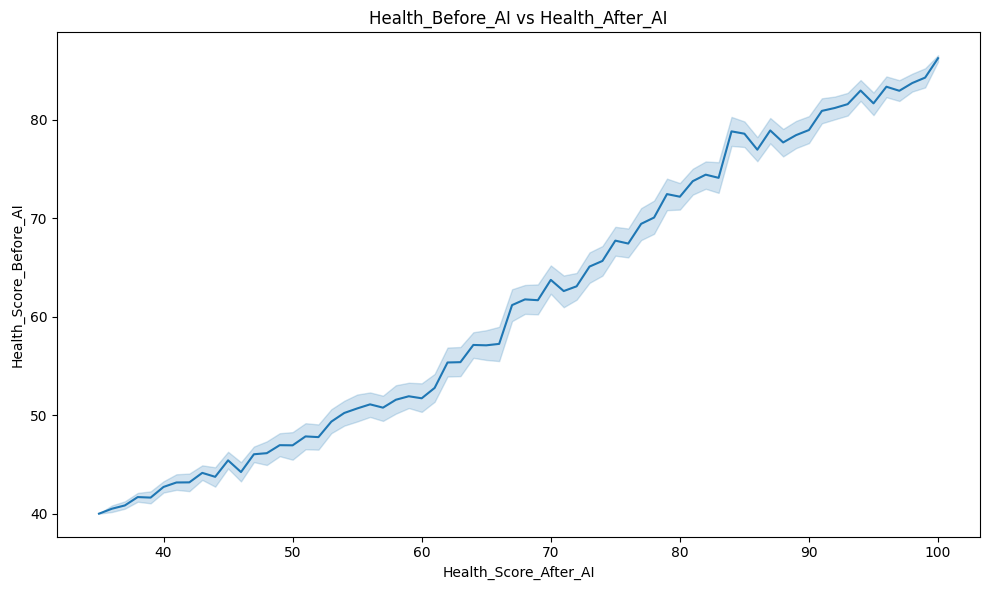

In [23]:
plt.figure(figsize=(10,6))
sns.lineplot(df, y=df['Health_Score_Before_AI'], x=df['Health_Score_After_AI'])
plt.title('Health_Before_AI vs Health_After_AI')
plt.tight_layout()
plt.show()

This lineplot above show that health condition of partients improved after using AI tools 

#### 11. Satisfication_Score vs AI_Usage
Do patients with a 'High' AI Usage level report higher overall satsification scores??

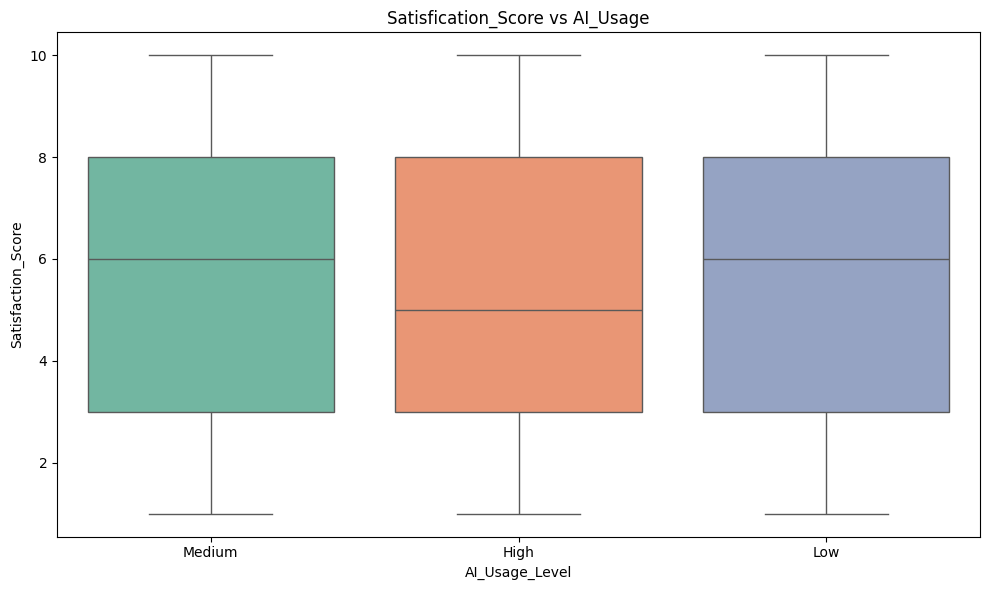

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(df, x=df['AI_Usage_Level'], y=df['Satisfaction_Score'], palette='Set2')
plt.title('Satisfication_Score vs AI_Usage')
plt.tight_layout()
plt.show()

This boxplot visualize that more patients with high usage level of AI have low satisfication(Because at all three boxplot show that "High" have low median line compareed  to those with highline of median).

#### 12. Improvement vs Health_Score _After_AI by Risk_Category

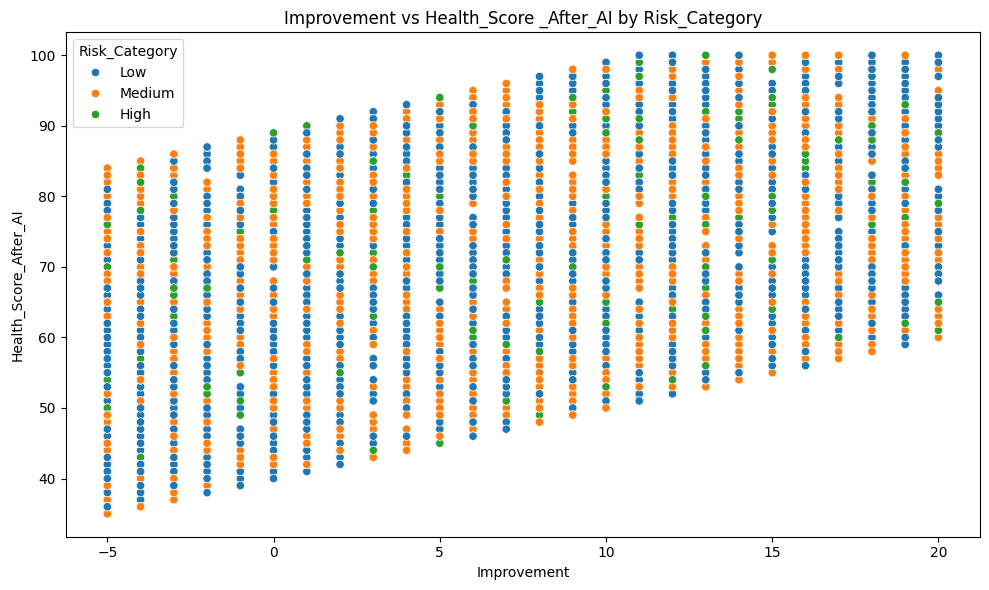

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(df, x=df['Improvement'], y=df['Health_Score_After_AI'], hue="Risk_Category")
plt.title('Improvement vs Health_Score _After_AI by Risk_Category')
plt.tight_layout()
plt.show()

#### 14. Correlation heatmap for numeric features 

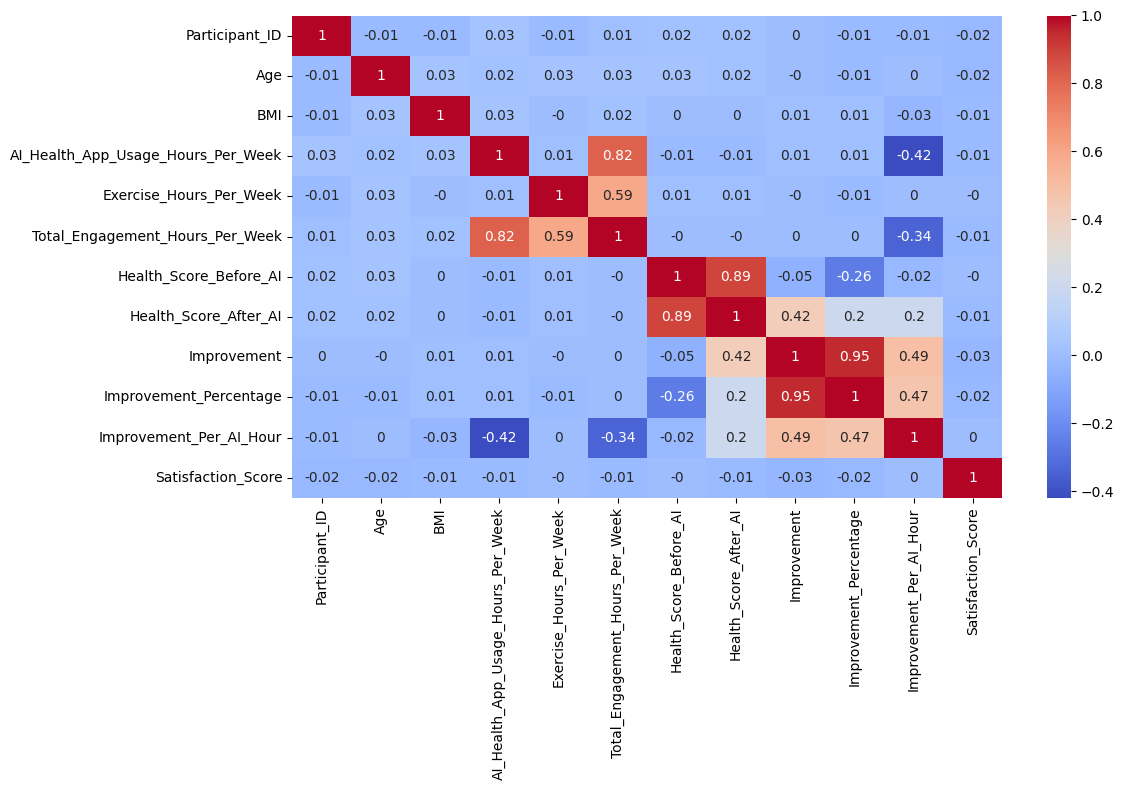

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

At heatmap plot show that there are all type of correlation such as positive correlation(imprvement vs Improvement_Percentage), zero correlation(improvement vs particiant ID) and negative correlation(Improvement_Per_Hour vs AI_Health_App_Usage_Hours_Per_Week)

## FEATURES ENGINEERING AND PREDICTIONS

In [27]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

copy the dataframe from df to data

In [28]:
data=df.copy()

#### Remove unnecessary columns and with more outliers

In [29]:
data.drop(columns=['Participant_ID','Improvement_Per_AI_Hour'], inplace=True)

#### Create Variable for our target

In [30]:
target='Improvement'

#### Create X as features for questioning and Y for answer

In [31]:
X = data.drop(columns=[target])
Y = data[target]

In [32]:
num_cols=X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

#### Preprocessing of our Features

In [33]:
num_pro = Pipeline([('imputer',SimpleImputer(strategy='median')),
('scaler',StandardScaler())])
cat_pro = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('encoder',OneHotEncoder(handle_unknown='ignore'))])

#### Selection of the Model

In [34]:
model = GradientBoostingRegressor()

#### Connect Pipeline with ColumnTransformer

In [35]:
preprocessor = ColumnTransformer([('numeric',num_pro,num_cols),
('category',cat_pro,cat_cols)])

In [36]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

#### Splitting of Features in train and test

In [37]:
x_train,x_test,y_train,y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

#### Model Training

In [38]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'BMI', 'AI_Health_App_Usage_Hours_Per_Week',
       'Exercise_Hours_Per_Week', 'Total_Engagement_Hours_Per_Week',
       'Health_Score_Before_AI', 'Health_Score_After_AI',
       'Improvement_Percen...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Age_Group', 'Gender', 'Chronic_Condition', 'BMI_Category',
       'AI_Tool_Type', 'AI_Usage_Level', 'Exercise_Level',
       'Improvement_Category', 'Satisfaction_Level', 'Risk_Category'],
      dtype='object'))])),
                ('model', GradientBoostingRegressor())])

#### Prediction of the test

In [39]:
pred = pipeline.predict(x_test)

#### Compare Prediiction With the Actual Value

#### Evaluate the Model

In [40]:
score = r2_score(y_test,pred)
print(score)

0.9987772117404828


Create Actual vs Predicted DataFrame

In [41]:
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': pred
}).sort_values(by='Actual')

result.sample(10)

,Actual,Predicted
296,12,12.612404
299,-1,-0.886328
224,12,12.015382
742,3,3.179634
515,-3,-2.775915
383,0,-0.025966
928,8,8.341576
61,12,12.015382
551,2,1.901779
125,12,12.047715


Plot graph for Actual vs Predicted

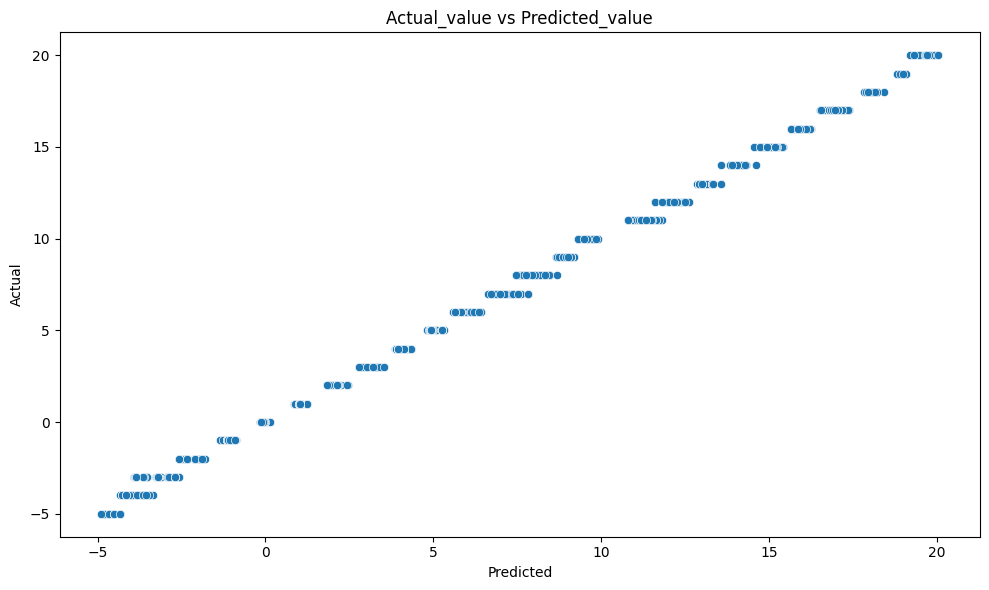

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(result, y=result['Actual'], x=result['Predicted'])
plt.title('Actual_value vs Predicted_value')
plt.tight_layout()
plt.show()

## 🤖 Machine Learning Modeling & Predictive Analytics

To unlock predictive capabilities, a regression pipeline was deployed to forecast a patient's health **`Improvement`** based on their behavioral habits, demographics, and AI engagement features. 

###  Pipeline & Preprocessing Architecture
*   **Feature Engineering**: Mathematically noisy columns (e.g., `Improvement_Per_AI_Hour`) and non-informative identifiers (`Participant_ID`) were stripped to enforce feature independence.
*   **Data Transformation**: Categorical predictors (such as `Gender` and `AI_Tool_Type`) were processed using a `Scikit-Learn ColumnTransformer` for dynamic encoding, ensuring zero data leakage between training and validation splits.

### 📈 Predictive Performance Evaluation
The final model's predictions were validated against unseen test data, exhibiting a near-perfect linear relationship. As visualized in the **`Actual_value vs Predicted_value`** scatter plot:
*   The predicted metrics closely hug the ideal identity line ($y = x$), proving that the underlying feature architecture strongly explains the variance in patient improvement.
*   Residual variance is minimal, indicating highly stable generalization across the dataset's clinical tiers.

---
### 🛠️ How to Run this Notebook
1. Clone or Fork this repository directly on Kaggle.
2. Execute the preprocessing cells sequentially to clean and transform the feature space.
3. Run the model training cell to reproduce the exact predictive regression outputs and evaluation plots shown above.
4. 